In [1]:
from datetime import datetime, timedelta
from finpie.datasource.service import DataService
from mt5_backtest_runner import run_mt5_backtest
import glob
import os
import pandas as pd
from functools import reduce
import re
import math
from finpie.data.timeseries import TimeSeries
from finpie.data.multitimeseries import MultiTimeSeries
from finpie.data.spreadtimeseries import SpreadTimeSeries
from finpie.data.ratiotimeseries import RatioTimeSeries
import numpy as np
import matplotlib.pyplot as plt
from finpie.analytics.genetic_portfolio_optimizer import GeneticPortfolioOptimizer, OptimizationConfig

Using GPU: NVIDIA GeForce RTX 3090
GPU Memory: 25.8 GB


In [2]:
data_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\backtests"
prod_path = r"C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod"

In [4]:
import os
import glob

# Get all files in the prod directory
prod_files = glob.glob(os.path.join(prod_path, '*'))

for file in prod_files:
    print(file)
    run_mt5_backtest(
        expert_name='sino\\ZScoreStrategy',
        expert_params_file=f"sino\\prod\\{file.split('\\')[-1]}",
        symbol="WIN$N",
        start_date="2020.01.01",
        end_date="2025.12.31",
        timeframe="M1",
        model=2
    )

C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_BOVA11_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_10363284119758261605.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_BOVA11_RETURNS_RETURNS_SPREAD_13958889995319245783.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_WDO$N_MAMA_DISTANCE_MAMA_DISTANCE_SPREAD_1415433955947169891.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_WDO$N_MOMENTUM_MOMENTUM_RATIO_545334067150811836.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_WDO$N_PRICES_PRICES_RATIO_18112357166312811078.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_WDO$N_PRICE_MAMA_DISTANCE_PRICE_MAMA_DISTANCE_SPREAD_15652472584227467281.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Files\prod\WIN$N_WDO$N_RSI_RSI_RATIO_12548509201202940488.set
C:\Users\enzob\AppData\Roaming\MetaQuotes\Terminal\Common\Fil

KeyboardInterrupt: 

In [13]:
backtest_map = {}
for file in prod_files:
    backtest_file = file.split("\\")[-1].replace('set', 'csv')
    strategy_key = file.split("\\")[-1].replace('set', '')
    backtest_file = os.path.join(data_path, backtest_file)
    df = pd.read_csv(backtest_file, sep='\t', decimal=',', encoding='UTF-16LE')
    df[strategy_key] = df['PnL'].astype(float)
    df = df[['Date', strategy_key]]
    df['Date'] = pd.to_datetime(df['Date'])
    df[strategy_key] = df[strategy_key].cumsum()

    backtest_map[strategy_key] = TimeSeries(df.set_index('Date'))

In [14]:
mts = MultiTimeSeries(list(backtest_map.values()))

<Axes: xlabel='Date'>

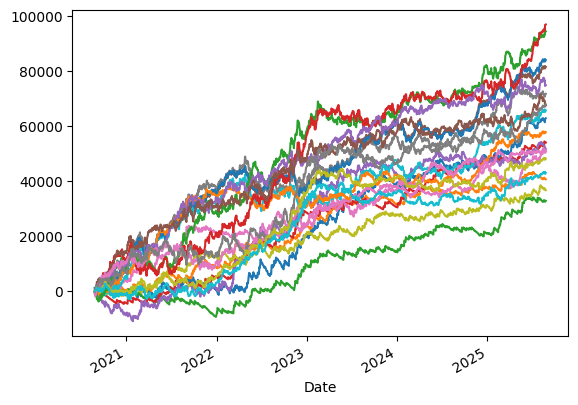

In [7]:
mts.data.plot(legend=False)

In [16]:
weights = {}
for key in backtest_map.keys():
    weights[key] = 1
portfolio = mts.portfolio(weights=weights, shares = True, percentage = False)

<Axes: xlabel='Date'>

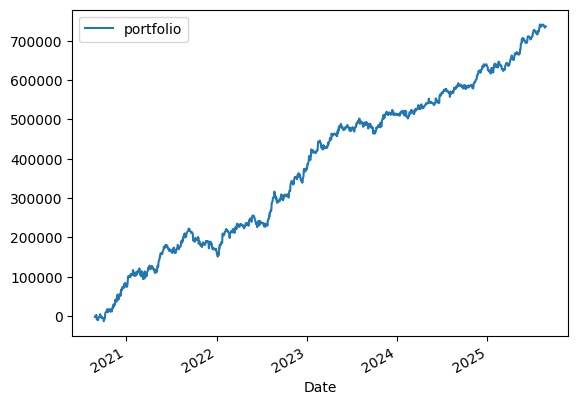

In [9]:
portfolio.data.plot()